# 1. Notebook kernel setup

After cloning repository at https://github.com/EstebanRivera08/PySonoGen, and the uv package, go on terminal to the location of the repository and run the following command to install the required packages:

`` uv run pycalib ``

To run these jupyter notebooks, the .venv environment of the project must be used as kernel.
To do so, from the repository path, you can run.

`` uv run -m ipykernel install --user --name=.venv --display-name "PySonoGen (.venv)" ``

This will create a jupyter kernel named 'PySonoGen (.venv)', that one can then select as kernel
of the notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
%load_ext autoreload
%autoreload 2


# 2. Define Matrix Transducer

In [2]:
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer']


In [3]:
# Create transducer with elevation focus
tx_N_elem_x = 55
tx_N_elem_y = 55
tx_elem_width_mm = 0.29
tx_elem_height_mm = 0.29

tx_pitch_mm = 0.3

tx_kerf_x_mm = tx_pitch_mm - tx_elem_width_mm
tx_kerf_y_mm = tx_pitch_mm - tx_elem_height_mm

tx_freq = 10 # MHz

directivity = 28 

c = 1540.0  # speed of sound in soft tissue (m/s)

Zeus_Matrix = Transducers.MatrixArrayTransducer(
        N_elem_x        = tx_N_elem_x,
        N_elem_y        = tx_N_elem_y,
        elem_width_mm   = tx_elem_width_mm,
        elem_height_mm  = tx_elem_height_mm,
        kerf_x_mm       = tx_kerf_x_mm,
        kerf_y_mm       = tx_kerf_y_mm,
        no_sub_x        = 3,
        no_sub_y        = 3,
        frequency_Hz    = tx_freq*1e6, 
        dir_angle_deg   = directivity
)

print(Zeus_Matrix)

MatrixArrayTransducer initialized with 3025 elements and 27225 patches.
Transducer initialized in 0.0981 seconds.
MatrixArrayTransducer(n_elem_x=55, n_elem_y=55, el_w_mm=0.29, kerf_x_mm=0.010000000000000009, kerf_y_mm=0.010000000000000009, no_sub_x=3, no_sub_y=3, fc_Hz=10000000.0)


In [4]:
# Focalization spot
focus_mm =  np.array([0, 0, 6.5])  # mm [x, y, z]

Focus: 0.000 mm, 0.000 mm, 6.500 mm


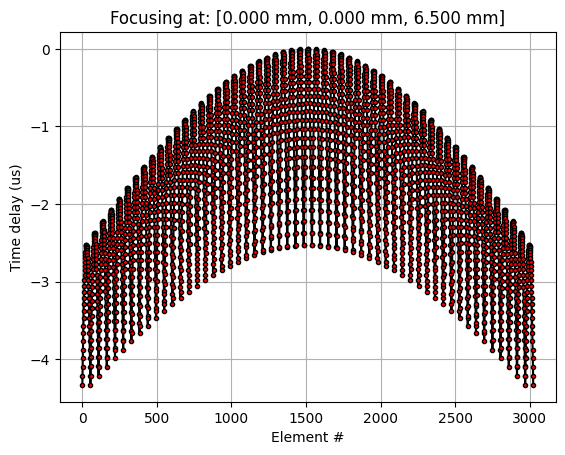

In [5]:
delays = Zeus_Matrix.compute_delays(focus_mm = focus_mm, plot = True)

Focus: 0.000 mm, 0.000 mm, 6.500 mm


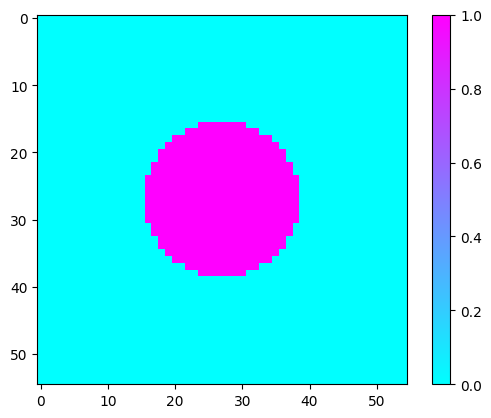

In [6]:
F_over_D = 2 
apodization = Zeus_Matrix.compute_apodization(focus_mm = focus_mm, apodization_type='circular', plot = True)

In [7]:
Zeus_Matrix.show()  # Add this parameter

Widget(value='<iframe src="http://localhost:54447/index.html?ui=P_0x1dad3858f80_0&reconnect=auto" class="pyvis…

# 3. Define field grid

In [8]:
import pysonogen
from pysonogen import pyfield


In [9]:
Zeus_Matrix_mesh = Zeus_Matrix.get_mesh()

In [10]:
Matrix_field = pyfield.PyField(Zeus_Matrix)

Successfully initialized PyField with 
 MatrixArrayTransducer(n_elem_x=55, n_elem_y=55, el_w_mm=0.29, kerf_x_mm=0.010000000000000009, kerf_y_mm=0.010000000000000009, no_sub_x=3, no_sub_y=3, fc_Hz=10000000.0)


In [11]:
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.25+focus_mm[1], 0.25+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.025,
    "dy" : 0.025,
    "dz" : 0.05,
}

In [12]:
pressure_field, x, y, z = Matrix_field.compute_pressure_field(field_info_mm)

Creating simulation grid...
Computing spatial impulse response...
Computing SIR for 18081 points and 27225 patches...
Computing all patch events...
Accumulating SIR from events...
Total computation time: 91.8766 seconds.
Computing pressure field...
Original h shape: (512, 18081)
Reshaped h shape: (512, 21, 21, 41)
Performing FFT...
Frequency searched: 10000000.0 Hz. Found: 9980430.528375736 Hz


Taking slice x_ind, y_ind, z_ind = 11/21, 11/21, 21/41


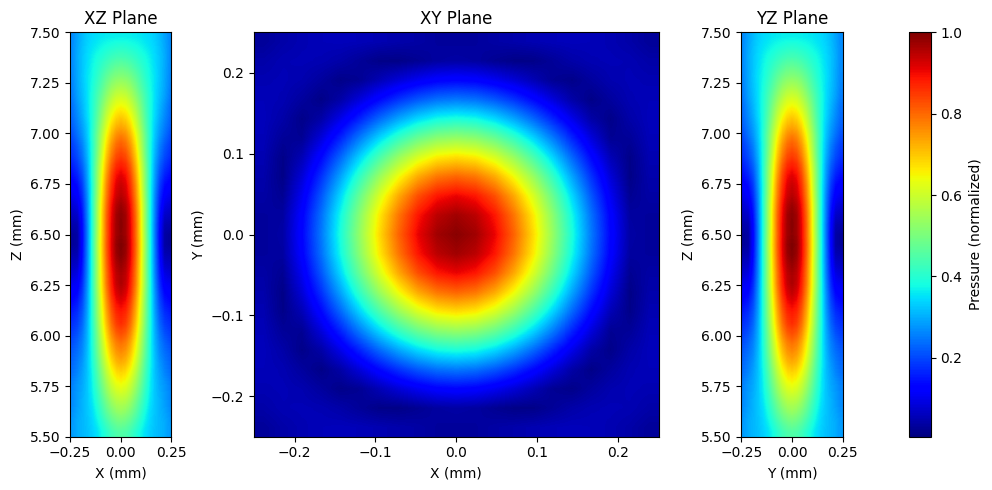

In [13]:
pysonogen.plot_field_planes(pressure_field,
                               x, y, z, figsize = (10, 5), interpolation="bilinear")

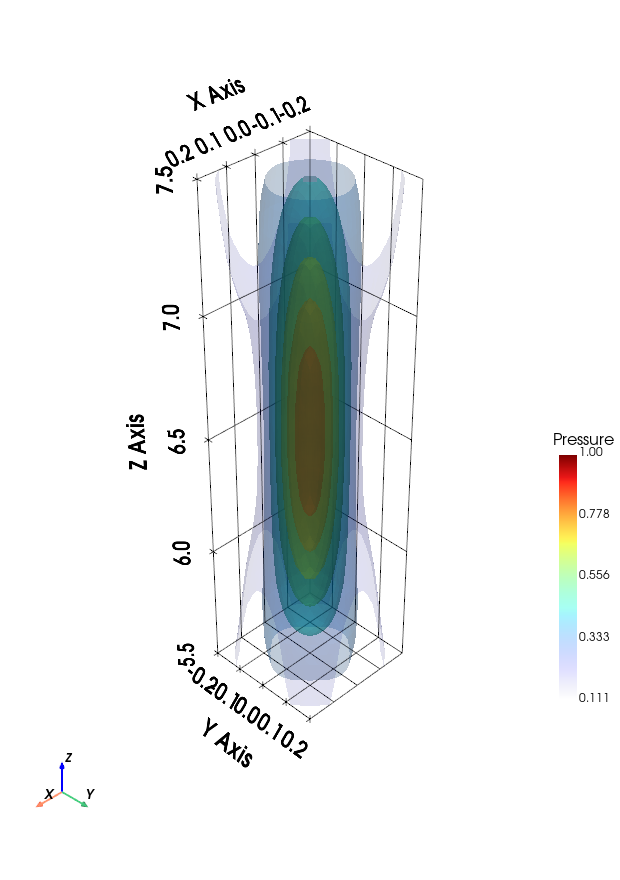

In [21]:
pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True, window_size = [620, 880])


pressure_plotter.show(jupyter_backend='static')  # Add this parameter

In [16]:

Ensemble_plotter = pv.Plotter(notebook=False)

Ensemble_plotter = pysonogen.add_transducer_to_plotter(Ensemble_plotter, Zeus_Matrix_mesh)
Ensemble_plotter = pysonogen.add_pressure_to_plotter(Ensemble_plotter, pressure_vol_mesh, plot_focal_spot=False )

Ensemble_plotter.add_axes()              # show XYZ axes
Ensemble_plotter.show_grid()             # show grid
Ensemble_plotter.camera.up = [0, 0, -1]  # set camera up direction
Ensemble_plotter.show()  # Add this parameter